# Jump King × PPO — a walkthrough of the core implementation

This notebook is the *short* version of the project: the pieces you need in order to
understand how a PPO agent learns to climb Jump King, each one runnable on its own so
you can poke at it.

What is here — the environment wrapper, the observation, the macro-action table, the
reward rule, the reverse curriculum, the actor-critic network, GAE, the clipped PPO
objective, a real (small) training run, and the deployed models playing.

What is **not** here — the parallel subprocess env (`VecEnv.py`), behaviour cloning
(`BC.py`), the BFS route prover (`LevelGraph.py`), wind/ice macro-actions, and the
per-level production line (`AutoPilot.py`). Those are in the repo; this notebook is the
core loop only.

**Run it from the project root** (paths like `starts/` and `checkpoints/` are relative),
top to bottom the first time. After section 1 most sections stand alone.

Requires: `pip install jupyter` (plus the project's `requirements.txt`).

## 0. Setup

`SDL_VIDEODRIVER=dummy` has to be set **before** pygame is imported by anything —
that is what lets the game run headless inside a notebook. `frame`/`show` render the
real game screen into a numpy array so we can look at it inline.

**One rule for this notebook:** pygame keeps the display and the keyboard hook as
*process-global* state, so only **one env may be alive at a time**. Always build envs
through `make_env()` — it closes the previous one first — and keep using the name `env`
for the live one. (The real trainer sidesteps this by putting every env in its own
subprocess; see `VecEnv.py`.)

In [1]:
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # headless: no window
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")   # and no sound device

import time, json, glob
import numpy as np
import torch
import torch.nn as nn
import pygame
import matplotlib.pyplot as plt
%matplotlib inline

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEV)
assert os.path.exists("JK_Env.py"), "run this notebook from the project root"


def frame(env):
    "The current game screen as an (H, W, 3) uint8 array."
    env.game_screen.fill((0, 0, 0))
    try:
        env.levels.blit1();
        env.king.blitme();
        env.babe.blitme();
        env.levels.blit2()
    except Exception as e:                      # cosmetic only
        print("blit warning:", e)
    return pygame.surfarray.array3d(env.game_screen).swapaxes(0, 1)


def show(env, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5.2, 4.0))
    ax.imshow(frame(env)); ax.set_title(title, fontsize=10); ax.axis("off")
    return ax


_LIVE = None

def make_env(**kwargs):
    "Build THE env, closing any previous one (pygame state is process-global)."
    global _LIVE
    if _LIVE is not None:
        try:
            _LIVE.close()
        except Exception:
            pass
    from JK_Env import JumpKingEnv
    _LIVE = JumpKingEnv(**kwargs)
    return _LIVE

pygame 2.6.1 (SDL 2.28.4, Python 3.13.14)
Hello from the pygame community. https://www.pygame.org/contribute.html
torch 2.13.0+cpu | device: cpu


C:\Users\Nemanja\Desktop\LastButNotLeast\BachelorProject\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 1. The game as an RL environment

`JK_Env.JumpKingEnv` wraps the pygame game in a Gymnasium-style
`reset() / step()` interface. Three things make it an RL problem rather than a game loop:

* **The agent only acts at grounded decision points.** One `step()` is a whole
  *macro-action* (charge a jump, release, fly, land, settle) — tens of physics frames.
  The agent never sees mid-air frames, so it cannot steer mid-jump, exactly like a human
  who has already committed to a jump.
* **The physics are deterministic** (except wind), so a state plus an action always give
  the same landing.
* **`goal_level`** turns the endless climb into a per-level episode: reaching level
  `goal_level` terminates the episode as a success.

We use level 4 → 5 throughout, with the start-state pool the real training used.

In [2]:
env = make_env(goal_level=5,                          # success = reach level 5
               max_steps=60,                          # macro-actions per episode
               start_states="starts/starts_L4.json",  # the start-state pool
               p_bottom=0.0,                          # never restart at the bottom
               curriculum=True,                       # easiest state first (section 5)
               cur_window=10,
               cur_advance_rate=0.6)
obs, info = env.reset()

print(f"num_actions : {env.num_actions}")
print(f"grid_shape  : {env.grid_shape}   ({env.grid_cell}px cells over a "
      f"{env.screen_w}x{env.screen_h} screen)")
print(f"n_scalars   : {env.n_scalars}")
print(f"obs_dim     : {env.obs_dim}  =  {env._grid_flat} grid  +  {env.n_scalars} scalars")
print(f"start pool  : {len(env._start_pool)} states")
print(f"spawned at  : level {env.levels.current_level}, "
      f"x={env.king.rect_x}, y={env.king.rect_y}")


num_actions : 23
grid_shape  : (3, 45, 60)   (8px cells over a 480x360 screen)
n_scalars   : 4
obs_dim     : 8104  =  8100 grid  +  4 scalars
start pool  : 14 states
spawned at  : level 4, x=50.0, y=64


In [3]:
env.actions
env.king.x
env.king.y

print(env.wind_obs)
print(env.king)

# Jedan makro-potez. Rezultat MORA da se preuzme: `step` pomera env, pa bi
# stari `obs` (iz `reset()`) od ovog trenutka opisivao stanje koje vise ne postoji.
obs, reward, terminated, truncated, info = env.step(0)

grid    = obs[:env._grid_flat].reshape(env.grid_shape)
grid


False


array([[[1., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 1.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(3, 45, 60), dtype=float32)

In [4]:
obs[:env._grid_flat]


array([1., 0., 0., ..., 0., 0., 0.], shape=(8100,), dtype=float32)

## 2. What the agent sees

The observation is **one flat vector** that packs two very different things:

1. an **occupancy grid** `(3, 45, 60)` — the screen at 8-pixel resolution, three channels:
   `0` solid ground, `1` the king's cell, `2` ice/snow (slippery). Built by
   `Occupancy.build_occupancy_grid` from the level's platform list — not from pixels, so
   decorative art never confuses it.
2. **4 scalars**: `x/W`, `y/H`, `level/max_level`, `altitude` (normalised). The grid is
   only 8-px accurate, and jumps need finer position sense than that — the scalars
   restore it.

Packing them into one vector keeps the buffer and the training loop unaware of the
structure; only the network unpacks it (section 6). Two optional pairs get appended for
the hard biomes: `wind_obs` (sin/cos of the wind phase) and `vel_obs` (the king's
velocity — needed on ice, where a landed king is still sliding).

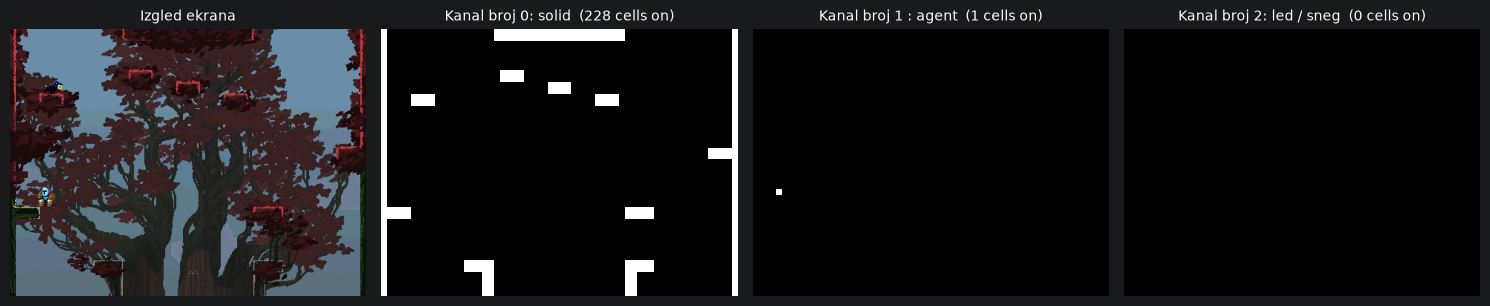

scalars [x, y, level/max (Normalizovano), altitude (normalizovano)] = [0.079 0.603 0.095 0.102]
obs vector: (8104,) float32 | grid part 8100, scalar part 4


In [5]:
# Svez obs, da grid i slika ekrana ne mogu da se raziđu bez obzira
# sta je izvrseno izmedju ove i prethodnih celija.
obs     = env._obs()
grid    = obs[:env._grid_flat].reshape(env.grid_shape)
scalars = obs[env._grid_flat:]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
axes[0].imshow(frame(env))
axes[0].set_title("Izgled ekrana", fontsize=10)
for i, name in enumerate(["Kanal broj 0: solid", "Kanal broj 1 : agent", "Kanal broj 2: led / sneg"]):
    axes[i + 1].imshow(grid[i], cmap="gray", interpolation="nearest")
    axes[i + 1].set_title(f"{name}  ({grid[i].sum():.0f} cells on)", fontsize=10)
for a in axes:
    a.axis("off")
plt.tight_layout(); plt.show()

print("scalars [x, y, level/max (Normalizovano), altitude (normalizovano)] =", np.round(scalars, 3))
print("obs vector:", obs.shape, obs.dtype,
      f"| grid part {env._grid_flat}, scalar part {env.n_scalars}")


### Where the hazard channel actually fires

On a grass level channel `2` is all zeros — nothing there is slippery, so the picture
above says nothing about it. The two biomes that light it up read very differently:

* **snow (levels 26–30)** — snow platforms are mixed in with plain land, so `hazard` is a
  genuine *subset* of `solid`: it tells the policy *which* of the ledges it can see will
  not brake the king on landing.
* **ice (levels 36–38)** — **every** platform is ice, so `hazard` comes out as a pixel-exact
  copy of `solid` and carries zero information. What matters there instead is *which way
  the ground is tilted*, because slip turns a ramp into an accelerator: the along-ramp
  deceleration drops from 0.35 to 0.10 per frame. That is the `slope` channel
  (`Occupancy.build_occupancy_grid`), signed in `[-1, +1]`, sign = the direction gravity
  drags the king along the ramp.

The channel set is configurable per level family, which is why the deployed L36–38
checkpoints store `grid_channels = ("solid", "slope")` — hazard dropped as redundant,
the king's position left to the scalars, and `vel_obs=True` added because a landed king
on ice is still moving. Below the ice env is built with all four planes so the
redundancy is visible side by side.

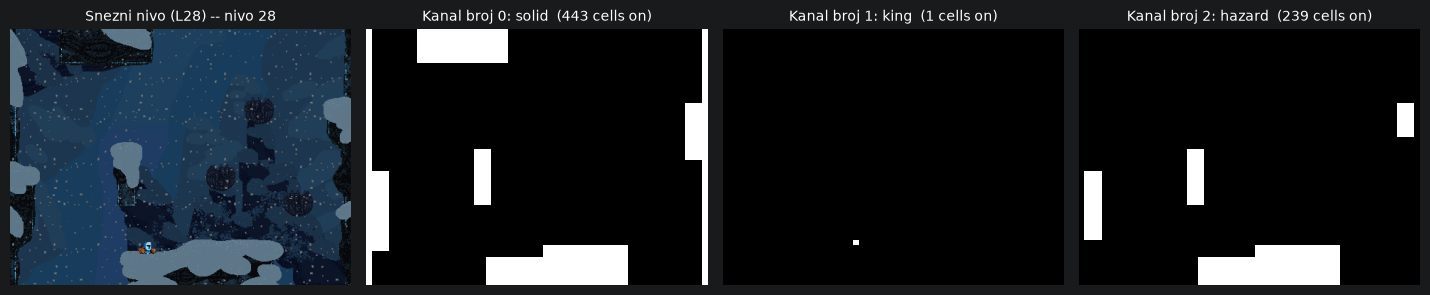

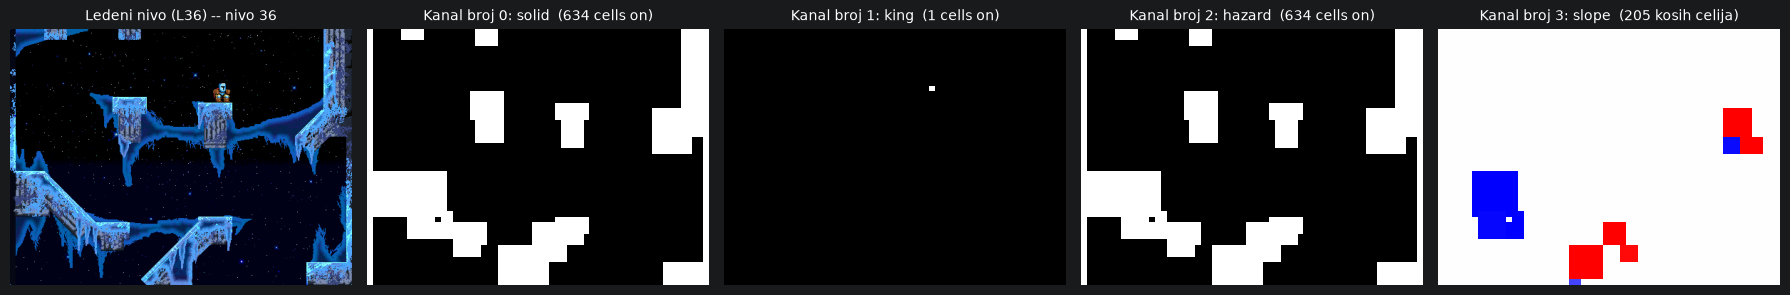

led: hazard == solid -> True | slope u opsegu [-1.00, +1.00]
zato deployed L36-38 modeli voze grid_channels = ('solid', 'slope'), vel_obs=True
env vracen na L4 -> L5; trenutni nivo: 4


In [6]:
# Kanal 2 (hazard) je prazan na travnatim nivoima -- da bi se video, treba nivo sa
# snegom ili ledom. Pravilo notebook-a i dalje vazi: samo JEDAN env sme da bude ziv,
# pa idemo redom kroz make_env(), a na kraju vracamo env iz sekcije 1.
import json

def channels_of(pool, goal, title, channels=None, **kw):
    "Postavi kralja na prvo start-stanje iz `pool` i nacrtaj ekran + sve kanale."
    s = json.load(open(pool))[0]
    e = make_env(goal_level=goal, max_steps=60, start_states=pool,
                 p_bottom=0.0, grid_channels=channels, **kw)
    obs, _ = e.reset(level=s["level"], rect_x=s["x"], rect_y=s["y"])
    grid = obs[:e._grid_flat].reshape(e.grid_shape)

    n = len(e.grid_channels)
    fig, axes = plt.subplots(1, n + 1, figsize=(3.6 * (n + 1), 3.2))
    axes[0].imshow(frame(e))
    axes[0].set_title(f"{title} -- nivo {e.levels.current_level}", fontsize=10)
    for i, name in enumerate(e.grid_channels):
        plane = grid[i]
        if name == "slope":                     # jedini kanal sa znakom: -1 .. +1
            axes[i + 1].imshow(plane, cmap="bwr", vmin=-1, vmax=1, interpolation="nearest")
            note = f"{int((plane != 0).sum())} kosih celija"
        else:
            axes[i + 1].imshow(plane, cmap="gray", interpolation="nearest")
            note = f"{plane.sum():.0f} cells on"
        axes[i + 1].set_title(f"Kanal broj {i}: {name}  ({note})", fontsize=10)
    for a in axes:
        a.axis("off")
    plt.tight_layout(); plt.show()
    return grid


# 1) SNEG (26-30): sneg i obicno tlo se mesaju -> hazard je PODSKUP solid-a.
snow = channels_of("starts/starts_L28.json", 29, "Snezni nivo (L28)")


# 2) LED (36-38): svaka platforma je led -> hazard je tacna kopija solid-a, nula
#    informacije. Zato ti nivoi umesto njega nose `slope`.
ice = channels_of("starts/starts_L36.json", 37, "Ledeni nivo (L36)",
                  channels=("solid", "king", "hazard", "slope"), vel_obs=True)
print("led: hazard == solid ->", np.array_equal(ice[0], ice[2]),
      f"| slope u opsegu [{ice[3].min():+.2f}, {ice[3].max():+.2f}]")
print("zato deployed L36-38 modeli voze grid_channels = ('solid', 'slope'), vel_obs=True")

# vrati env iz sekcije 1 da ostatak notebook-a nastavi kao pre
env = make_env(goal_level=5, max_steps=60, start_states="starts/starts_L4.json",
               p_bottom=0.0, curriculum=True, cur_window=10, cur_advance_rate=0.6)
obs, info = env.reset()
print("env vracen na L4 -> L5; trenutni nivo:", env.levels.current_level)

## 3. Macro-actions

The raw game is "hold a direction, hold space for N frames, release". Exposing that
frame-by-frame would make the horizon hopeless, so the action space is a small table of
**complete moves**. The default table is 23 actions:

* `("jump", direction, charge)` for `direction ∈ {left, up, right}` × 7 charges → 21
* `("walk", left|right, 10 frames)` → 2

`build_action_table` is the single source of truth for what an index *means*. Two models
trained with different tables are **not** index-compatible, which is why every checkpoint
stores its `action_cfg`. The deployed models use the frozen 37-action set: the 23 above +
fine 3-frame walks + extra charges `22, 24, 28, 30` appended at the end (appending keeps
old indices valid).

In [7]:
from JK_Env import build_action_table

tbl = build_action_table()          # the defaults this env was built with
print(f"{len(tbl)} actions\n")
for i, a in enumerate(tbl):
    print(f"{i:2d}  {a}")

print("\nthe deployed 37-action set adds:")
big = build_action_table(fine_walk_frames=3, extra_charges=(22, 24, 28, 30))
for i in range(len(tbl), len(big)):
    print(f"{i:2d}  {big[i]}")

23 actions

 0  ('jump', 'left', 4)
 1  ('jump', 'left', 8)
 2  ('jump', 'left', 12)
 3  ('jump', 'left', 16)
 4  ('jump', 'left', 20)
 5  ('jump', 'left', 26)
 6  ('jump', 'left', 32)
 7  ('jump', 'up', 4)
 8  ('jump', 'up', 8)
 9  ('jump', 'up', 12)
10  ('jump', 'up', 16)
11  ('jump', 'up', 20)
12  ('jump', 'up', 26)
13  ('jump', 'up', 32)
14  ('jump', 'right', 4)
15  ('jump', 'right', 8)
16  ('jump', 'right', 12)
17  ('jump', 'right', 16)
18  ('jump', 'right', 20)
19  ('jump', 'right', 26)
20  ('jump', 'right', 32)
21  ('walk', 'left', 10)
22  ('walk', 'right', 10)

the deployed 37-action set adds:
23  ('walk', 'left', 3)
24  ('walk', 'right', 3)
25  ('jump', 'left', 22)
26  ('jump', 'left', 24)
27  ('jump', 'left', 28)
28  ('jump', 'left', 30)
29  ('jump', 'up', 22)
30  ('jump', 'up', 24)
31  ('jump', 'up', 28)
32  ('jump', 'up', 30)
33  ('jump', 'right', 22)
34  ('jump', 'right', 24)
35  ('jump', 'right', 28)
36  ('jump', 'right', 30)


### One action, start to finish

Action 20 is `("jump", "right", 32)` — a full-power jump to the right. One `step()` runs
the whole charge → launch → flight → landing → settle sequence and returns only the
settled state.

From the state the curriculum starts us on, this one action *is* the crossing into level
5: the episode ends immediately with `success=True` and a reward around `+21` (`+10` for
the level climbed, `+10` for reaching `goal_level`, plus the altitude breadcrumb).
Finding that one action among 23 — from a state where 22 of the others waste the attempt
or drop him a screen — is what section 9 is about.

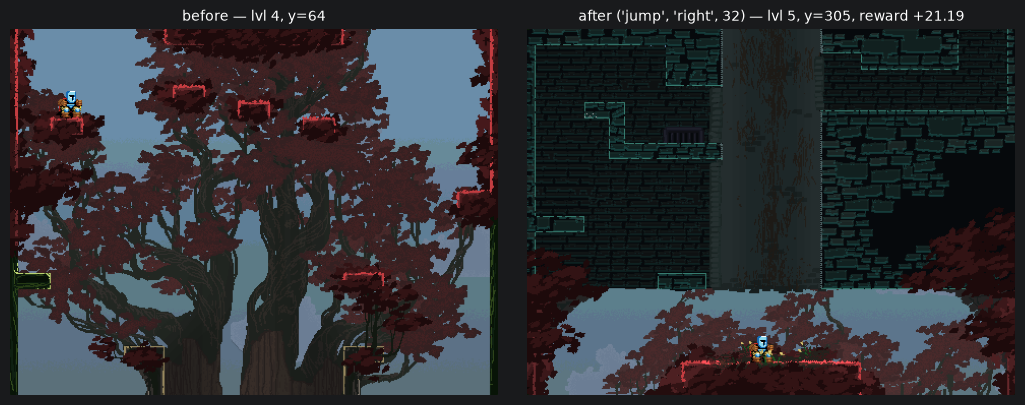

terminated: True | truncated: False | success: True


In [8]:
obs, _ = env.reset()
before, lvl0, y0 = frame(env), env.levels.current_level, env.king.rect_y

A = 20                                    # ("jump", "right", 32)
obs, r, term, trunc, info = env.step(A)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
ax[0].imshow(before);      ax[0].set_title(f"before — lvl {lvl0}, y={y0}", fontsize=10)
ax[1].imshow(frame(env));  ax[1].set_title(
    f"after {env.actions[A]} — lvl {info['level']}, y={info['y']}, reward {r:+.2f}",
    fontsize=10)
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

print("terminated:", term, "| truncated:", trunc, "| success:", info["success"])

## 4. Reward and when an episode ends

The reward is deliberately blunt, because in Jump King the only thing that matters is
which screen you are on:

| event | reward |
|---|---|
| climbed one level | `+10` per level |
| **fell** one level | `−10` per level |
| new maximum altitude within the level | `+0.01 ×` pixels gained |
| reached `goal_level` | `+10` |
| reached the babe (top of the game) | `+100` |

The altitude breadcrumb only pays for a *new* maximum, so hopping in place earns nothing
and there is no local optimum in re-treading height.

An episode ends when: the goal level is reached (success), the king **falls below the
level he started on** (failure — a per-level model should not have to re-climb), the
physics fail to settle, or `max_steps` is hit (truncation, not failure).

The run below is a random policy, so mostly you will see it flail — that is the point:
this is the exploration problem PPO has to solve.

In [9]:
np.random.seed(1)
wins = 0
for ep in range(5):
    obs, _ = env.reset()
    total = 0.0
    print(f"episode {ep}: start level {env.levels.current_level} "
          f"at x={env.king.rect_x:.0f} y={env.king.rect_y}")
    for t in range(12):
        a = np.random.randint(env.num_actions)
        obs, r, term, trunc, info = env.step(a)
        total += r
        print(f"   t={t:2d}  {str(env.actions[a]):22s} r={r:+7.3f}  "
              f"lvl={info['level']}  y={info['y']:3d}  alt={info['altitude']:6.0f}")
        if term or trunc:
            why = ("SUCCESS — reached the goal level" if info["success"]
                   else "TRUNCATED — hit max_steps" if trunc
                   else "FAILED — fell below the starting level (or physics stalled)")
            print(f"   -> {why}, return {total:+.2f}\n")
            wins += bool(info["success"])
            break
    else:
        print(f"   -> still going after 12 steps, return {total:+.2f}\n")

print(f"random policy: {wins}/5 episodes reached level 5")

episode 0: start level 4 at x=50 y=64
   t= 0  ('jump', 'left', 26)   r= -0.000  lvl=4  y=217  alt=  1583
   t= 1  ('jump', 'up', 20)     r= -0.000  lvl=4  y=217  alt=  1583
   t= 2  ('jump', 'up', 26)     r= -0.000  lvl=4  y=217  alt=  1583
   t= 3  ('jump', 'up', 8)      r= -0.000  lvl=4  y=217  alt=  1583
   t= 4  ('jump', 'up', 12)     r= -0.000  lvl=4  y=217  alt=  1583
   t= 5  ('jump', 'up', 20)     r= -0.000  lvl=4  y=217  alt=  1583
   t= 6  ('jump', 'left', 26)   r=-30.000  lvl=1  y= 79  alt=   641
   -> FAILED — fell below the starting level (or physics stalled), return -30.00

episode 1: start level 4 at x=50 y=64
   t= 0  ('jump', 'right', 8)   r=-20.000  lvl=2  y=185  alt=   895
   -> FAILED — fell below the starting level (or physics stalled), return -20.00

episode 2: start level 4 at x=50 y=64
   t= 0  ('jump', 'left', 4)    r= -0.000  lvl=4  y=217  alt=  1583
   t= 1  ('jump', 'right', 12)  r=-20.000  lvl=2  y=200  alt=   880
   -> FAILED — fell below the starting lev

## 5. Start states and the reverse curriculum

A random policy essentially never reaches the exit of a level from the bottom, so there
is no reward to learn from. The fix is a **reverse curriculum**: start the agent near the
exit, and only once it succeeds there, start it further away.

`starts/starts_L<N>.json` is that pool — grounded spots on level `N` (hand-captured with
the fly mode in `Capture.py`, proven by the BFS in `LevelGraph.py`, and extended with the
real arrival states of level `N−1`'s model by `Handoff.py`).

The env ranks them easiest-first (by validator score, then height), unlocks only the
first one, and unlocks the next when the recent success rate passes `cur_advance_rate`.
Within the unlocked set, sampling is **prioritised by a per-state failure EMA** — the
state the agent keeps failing is the one it gets rehearsed on (`focus` in the status
dict).

8 start states; first three: [{'level': 8, 'x': 64, 'y': 272, 'score': 0.0}, {'level': 8, 'x': 56, 'y': 272, 'score': 0.0}, {'level': 8, 'x': 68, 'y': 272, 'score': 0.0}]


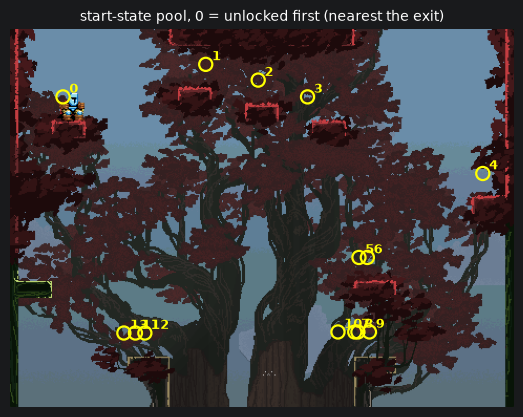

curriculum status: {'unlocked': 1, 'total': 14, 'p_bottom': 0.0, 'succ_rate': 0.33, 'focus': (50, 64, 0.84)}

unlocked  = how many of the ranked states resets may sample from
focus     = (x, y, failure-EMA) of the state the sampler is grinding on

the state we keep spawning on is state 0 -- one action from the exit


In [10]:
obs, _ = env.reset()          # back to level 4 after the random rollout above
pool = json.load(open("starts/starts_L8.json")) # ovo sam dirao
print(f"{len(pool)} start states; first three:", pool[:3])

ranked = env._cp_ranked                 # the env's easiest-first ordering
img = frame(env)
fig, ax = plt.subplots(figsize=(6.5, 5.0))
ax.imshow(img)
for i, s in enumerate(ranked):
    ax.scatter(s["x"], s["y"], s=90, edgecolor="yellow", facecolor="none", linewidth=1.6)
    ax.text(s["x"] + 6, s["y"] - 4, str(i), color="yellow", fontsize=9, weight="bold")
ax.set_title("start-state pool, 0 = unlocked first (nearest the exit)", fontsize=10)
ax.axis("off"); plt.show()

print("curriculum status:", env.curriculum_status())
print("\nunlocked  = how many of the ranked states resets may sample from")
print("focus     = (x, y, failure-EMA) of the state the sampler is grinding on")
print("\nthe state we keep spawning on is state 0 -- one action from the exit")

## 6. The network

One shared trunk, two heads — the standard actor-critic. The trunk has to cope with the
packed observation, so it splits the vector back apart: three stride-2 convolutions over
the `(3, 45, 60)` grid, then the scalars concatenated onto the flattened conv features,
then two `tanh` layers.

* **policy head** → logits over the action table (a `Categorical` distribution)
* **value head** → one number, the state value `V(s)`

The policy head is initialised with gain `0.01` so the initial policy is near-uniform:
at the start the agent should explore, not commit.

This is the same architecture as `PPO.ActorCritic` — written out here so you can see it
whole.

(3, 45, 60)
MiniActorCritic(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1540, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (policy_head): Linear(in_features=128, out_features=23, bias=True)
  (value_head): Linear(in_features=128, out_features=1, bias=True)
)

parameters: 231192
V(s) = -0.129   |   max action prob = 0.044 (uniform would be 0.043)


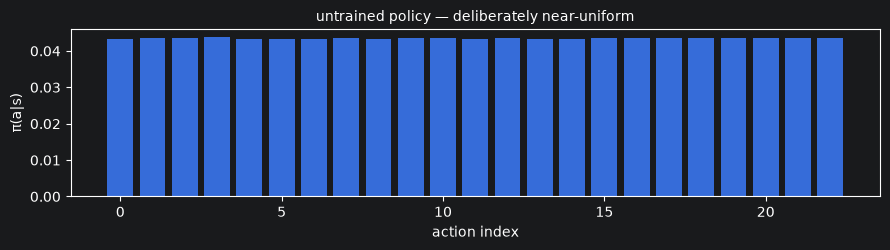

In [11]:
class MiniActorCritic(nn.Module):
    "Same architecture as PPO.ActorCritic's CNN branch, spelled out."

    def __init__(self, grid_shape, n_scalars, num_actions, hidden=128):
        super().__init__()
        C, H, W = grid_shape
        self.grid_shape, self.grid_flat = grid_shape, C * H * W
        self.conv = nn.Sequential(
            nn.Conv2d(C, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten())
        with torch.no_grad():
            conv_out = self.conv(torch.zeros(1, C, H, W)).shape[1]
        self.trunk = nn.Sequential(
            nn.Linear(conv_out + n_scalars, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh())
        self.policy_head = nn.Linear(hidden, num_actions)
        self.value_head = nn.Linear(hidden, 1)
        self.apply(self._init)
        nn.init.orthogonal_(self.policy_head.weight, 0.01)   # near-uniform start

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.orthogonal_(m.weight, np.sqrt(2))
            nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        g = x[:, :self.grid_flat].reshape(-1, *self.grid_shape)   # unpack the grid
        s = x[:, self.grid_flat:]                                  # and the scalars
        h = self.trunk(torch.cat([self.conv(g), s], dim=1))
        return self.policy_head(h), self.value_head(h).squeeze(-1)


net = MiniActorCritic(env.grid_shape, env.n_scalars, env.num_actions).to(DEV)
print(net.grid_shape)
print(net)
print("\nparameters:", sum(p.numel() for p in net.parameters()))

obs, _ = env.reset()
ob = torch.as_tensor(obs, device=DEV).float().unsqueeze(0)
with torch.no_grad():
    logits, value = net(ob)
probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

print(f"V(s) = {value.item():+.3f}   |   max action prob = {probs.max():.3f} "
      f"(uniform would be {1/env.num_actions:.3f})")
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(range(len(probs)), probs)
ax.set_xlabel("action index"); ax.set_ylabel("π(a|s)")
ax.set_title("untrained policy — deliberately near-uniform", fontsize=10)
plt.tight_layout(); plt.show()

## 7. Rollouts and GAE

PPO is on-policy: collect a fixed-length rollout with the *current* policy, learn from it,
throw it away. For each step we store the observation, the action, its log-probability
**detached** (it becomes the "old" policy in the ratio), the reward, and `V(s)`.

Then **GAE** turns rewards into advantages. The subtlety worth knowing:

* at a **terminated** step there is no future → zero the bootstrap;
* at a **truncated** step the episode was cut by the time limit but physically continues
  → still bootstrap, just do not let the advantage propagate across the cut.

Getting this backwards silently teaches the agent that running out of time is death.

batch: {'obs': (64, 8104), 'act': (64,), 'logp': (64,), 'adv': (64,), 'ret': (64,), 'val': (64,)}
episodes finished in this rollout: 16  (successes: 1)
advantage: mean -11.581  std 6.040  min -19.883  max +21.319


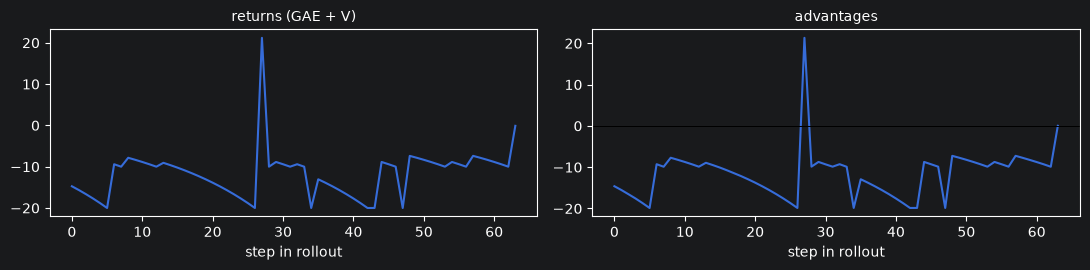

In [12]:
def gae(rew, val, term, trunc, last_val, gamma=0.99, lam=0.95):
    "Generalised Advantage Estimation over one (T,) rollout."
    T = len(rew)
    adv = torch.zeros(T, device=rew.device)
    running = torch.zeros((), device=rew.device)
    for t in reversed(range(T)):
        next_val = last_val if t == T - 1 else val[t + 1]
        nonterminal = 1.0 - term[t]                      # terminated -> no future
        cut = torch.clamp(term[t] + trunc[t], max=1.0)   # either -> stop propagating
        delta = rew[t] + gamma * next_val * nonterminal - val[t]
        running = delta + gamma * lam * (1.0 - cut) * running
        adv[t] = running
    return adv, adv + val                                 # advantages, returns


@torch.no_grad()
def collect(e, net, T, obs):
    "T macro-steps with the current policy -> a flat PPO batch."
    O = torch.zeros(T, e.obs_dim, device=DEV)
    A = torch.zeros(T, dtype=torch.long, device=DEV)
    LP = torch.zeros(T, device=DEV); R = torch.zeros(T, device=DEV)
    V = torch.zeros(T, device=DEV)
    TERM = torch.zeros(T, device=DEV); TRUNC = torch.zeros(T, device=DEV)
    successes = []
    for t in range(T):
        ob = torch.as_tensor(obs, device=DEV).float().unsqueeze(0)
        logits, v = net(ob)
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        O[t], A[t], LP[t], V[t] = ob[0], a[0], dist.log_prob(a)[0], v[0]
        obs, r, term, trunc, info = e.step(int(a))
        R[t], TERM[t], TRUNC[t] = r, float(term), float(trunc)
        if term or trunc:
            successes.append(1.0 if info["success"] else 0.0)
            obs, _ = e.reset()
    last_val = net(torch.as_tensor(obs, device=DEV).float().unsqueeze(0))[1][0]
    adv, ret = gae(R, V, TERM, TRUNC, last_val)
    return dict(obs=O, act=A, logp=LP, adv=adv, ret=ret, val=V), obs, successes


obs, _ = env.reset()
batch, obs, succ = collect(env, net, 64, obs)
print("batch:", {k: tuple(v.shape) for k, v in batch.items()})
print(f"episodes finished in this rollout: {len(succ)}  (successes: {int(sum(succ))})")
print(f"advantage: mean {batch['adv'].mean():+.3f}  std {batch['adv'].std():.3f}  "
      f"min {batch['adv'].min():+.3f}  max {batch['adv'].max():+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].plot(batch["ret"].cpu()); ax[0].set_title("returns (GAE + V)", fontsize=10)
ax[1].plot(batch["adv"].cpu()); ax[1].axhline(0, color="k", lw=0.7)
ax[1].set_title("advantages", fontsize=10)
for a in ax:
    a.set_xlabel("step in rollout")
plt.tight_layout(); plt.show()

## 8. The PPO update

The whole point of PPO: reuse each rollout for several epochs without letting the policy
move too far from the one that collected it. The ratio
`r = π_new(a|s) / π_old(a|s)` is clipped to `[1−ε, 1+ε]`, and we take the **pessimistic**
of the clipped and unclipped surrogate — so an advantage can never be exploited by
pushing the ratio arbitrarily far.

Total loss = policy loss + `vf_coef ×` value loss − `ent_coef ×` entropy. The entropy
bonus is not decoration here: with sparse reward and one precise winning jump per level,
too little entropy collapses the policy onto a wrong action, too much explores the
winning jump straight back out again.

Diagnostics to watch: `approx_kl` (how far the policy moved), `clipfrac` (how often the
clip bound bound), `entropy` (falling = the policy is committing).

In [13]:
def ppo_update(net, opt, b, clip=0.2, epochs=4, minibatches=4,
               vf_coef=0.5, ent_coef=0.01, max_grad_norm=0.5):
    n = b["obs"].shape[0]
    mb_size = max(1, n // minibatches)
    idx = np.arange(n)
    logs = {"policy_loss": 0., "value_loss": 0., "entropy": 0.,
            "approx_kl": 0., "clipfrac": 0.}
    k = 0
    for _ in range(epochs):
        np.random.shuffle(idx)
        for start in range(0, n, mb_size):
            j = torch.as_tensor(idx[start:start + mb_size], device=DEV)
            if len(j) < 2:
                continue

            adv = b["adv"][j]
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)     # per-minibatch norm

            logits, value = net(b["obs"][j])
            dist = torch.distributions.Categorical(logits=logits)
            new_logp = dist.log_prob(b["act"][j])
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_logp - b["logp"][j])        # old logp is detached
            policy_loss = -torch.min(ratio * adv,
                                     torch.clamp(ratio, 1 - clip, 1 + clip) * adv).mean()
            value_loss = ((value - b["ret"][j]) ** 2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), max_grad_norm)
            opt.step()

            with torch.no_grad():
                logs["approx_kl"] += (b["logp"][j] - new_logp).mean().item()
                logs["clipfrac"] += ((ratio - 1).abs() > clip).float().mean().item()
            logs["policy_loss"] += policy_loss.item()
            logs["value_loss"] += value_loss.item()
            logs["entropy"] += entropy.item()
            k += 1
    return {key: v / max(k, 1) for key, v in logs.items()}


opt = torch.optim.Adam(net.parameters(), lr=3e-4)
print("one update on the rollout from section 7:")
for key, v in ppo_update(net, opt, batch).items():
    print(f"  {key:12s} {v:+.4f}")

one update on the rollout from section 7:
  policy_loss  -0.0259
  value_loss   +94.9266
  entropy      +3.1338
  approx_kl    -0.0056
  clipfrac     +0.0039


## 9. Training

Everything above, in a loop: collect → update → repeat. This runs **level 4 → 5** for 30
updates × 128 macro-steps ≈ 3 800 steps, about 90 seconds on a CPU.

Two deviations from the real `Train.py`, both for the notebook's sake: one env in-process
instead of 8 in subprocesses (`VecEnv.py` uses subprocesses because pygame keeps
process-global state — two envs in one process stomp on each other), and a much shorter
run. Real levels get 10⁵–10⁶ steps.

Expect success to climb from ~0.0–0.2 to roughly **0.6–0.85**, while entropy falls from
3.14 (= `ln 23`, a uniform policy over the 23 actions) toward ~2.5: the agent finding the
one crossing action and starting to commit to it.

It is a short run of a stochastic policy, so the curve wobbles — pass a different `seed=`
to see the spread. If you let it run long enough to pass `cur_advance_rate`, the
curriculum unlocks a second, harder start state and success **drops** — that dip is the
curriculum working, not the agent forgetting.

In [14]:
def train(level=4, updates=30, T=128, lr=5e-4, ent_coef=0.01, seed=0, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)

    # a fresh env => a fresh curriculum; make_env closes the previous one
    e = make_env(goal_level=level + 1, max_steps=60,
                 start_states=f"starts/starts_L{level}.json", p_bottom=0.0,
                 curriculum=True, cur_window=10, cur_advance_rate=0.6)
    agent = MiniActorCritic(e.grid_shape, e.n_scalars, e.num_actions).to(DEV)
    opt = torch.optim.Adam(agent.parameters(), lr=lr)

    hist = {"succ": [], "entropy": [], "return": [], "unlocked": []}
    obs, _ = e.reset()
    t0 = time.time()
    for upd in range(1, updates + 1):
        batch, obs, successes = collect(e, agent, T, obs)
        logs = ppo_update(agent, opt, batch, ent_coef=ent_coef)

        succ = float(np.mean(successes)) if successes else float("nan")
        status = e.curriculum_status()
        hist["succ"].append(succ)
        hist["entropy"].append(logs["entropy"])
        hist["return"].append(batch["ret"].mean().item())
        hist["unlocked"].append(status["unlocked"])
        if verbose:
            print(f"upd {upd:3d} | succ {succ:4.2f} ({len(successes):2d} eps) | "
                  f"entropy {logs['entropy']:.2f} | kl {logs['approx_kl']:+.4f} | "
                  f"unlocked {status['unlocked']}/{status['total']}")
    print(f"\n{updates} updates in {time.time() - t0:.0f}s "
          f"({updates * T} macro-steps)")
    return agent, e, hist


agent, env, hist = train()      # `env` is rebound to the (new) live env

upd   1 | succ 0.22 (36 eps) | entropy 3.13 | kl -0.0006 | unlocked 1/14
upd   2 | succ 0.12 (34 eps) | entropy 3.08 | kl +0.0325 | unlocked 1/14
upd   3 | succ 0.19 (31 eps) | entropy 3.04 | kl +0.0083 | unlocked 1/14
upd   4 | succ 0.29 (31 eps) | entropy 2.99 | kl +0.0088 | unlocked 1/14
upd   5 | succ 0.37 (27 eps) | entropy 2.91 | kl +0.0019 | unlocked 1/14
upd   6 | succ 0.54 (37 eps) | entropy 3.01 | kl +0.0830 | unlocked 1/14
upd   7 | succ 0.13 (38 eps) | entropy 3.06 | kl +0.0400 | unlocked 1/14
upd   8 | succ 0.49 (45 eps) | entropy 2.87 | kl +0.0041 | unlocked 1/14
upd   9 | succ 0.38 (42 eps) | entropy 3.06 | kl +0.0233 | unlocked 1/14
upd  10 | succ 0.26 (31 eps) | entropy 2.92 | kl +0.0447 | unlocked 1/14
upd  11 | succ 0.68 (47 eps) | entropy 2.59 | kl +0.0024 | unlocked 1/14
upd  12 | succ 0.51 (39 eps) | entropy 2.95 | kl +0.0824 | unlocked 1/14
upd  13 | succ 0.28 (32 eps) | entropy 2.94 | kl -0.0048 | unlocked 1/14
upd  14 | succ 0.38 (45 eps) | entropy 2.86 | kl +0

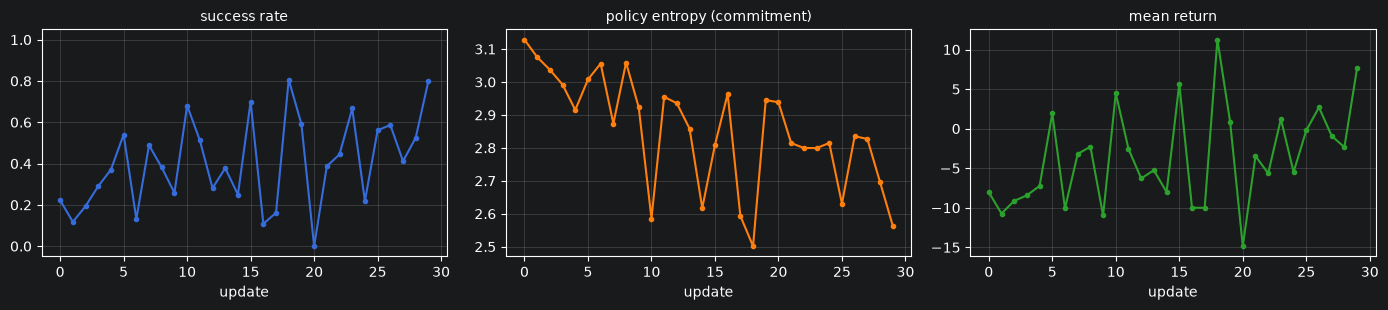

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
ax[0].plot(hist["succ"], marker="o", ms=3); ax[0].set_ylim(-0.05, 1.05)
ax[0].set_title("success rate", fontsize=10)
ax[1].plot(hist["entropy"], marker="o", ms=3, color="tab:orange")
ax[1].set_title("policy entropy (commitment)", fontsize=10)
ax[2].plot(hist["return"], marker="o", ms=3, color="tab:green")
ax[2].set_title("mean return", fontsize=10)
for a in ax:
    a.set_xlabel("update"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Watching what it learned

Greedy (`argmax`) rollout of the agent we just trained, from a start state in its pool.

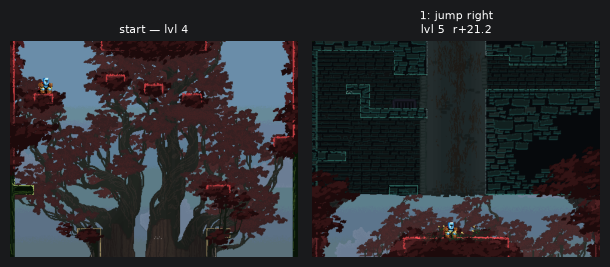

success: True | ended on level 5


In [16]:
obs, _ = env.reset()
frames = [frame(env)]
labels = [f"start — lvl {env.levels.current_level}"]
for t in range(20):
    with torch.no_grad():
        logits, _ = agent(torch.as_tensor(obs, device=DEV).float().unsqueeze(0))
    a = int(logits.argmax(1))
    obs, r, term, trunc, info = env.step(a)
    frames.append(frame(env))
    labels.append(f"{t+1}: {env.actions[a][0]} {env.actions[a][1]}\nlvl {info['level']}  r{r:+.1f}")
    if term or trunc:
        break

k = min(5, len(frames))
pick = np.linspace(0, len(frames) - 1, k).astype(int)
fig, axes = plt.subplots(1, k, figsize=(3.1 * k, 2.9))
for ax_, i in zip(np.atleast_1d(axes), pick):
    ax_.imshow(frames[i]); ax_.set_title(labels[i], fontsize=8); ax_.axis("off")
plt.tight_layout(); plt.show()
print("success:", info["success"], "| ended on level", info["level"])

## 10. The deployed models

The models in `checkpoints/L<N>/` are the same architecture trained the same way, just
much longer and with the extras this notebook skipped. Each checkpoint stores its
`action_cfg`, so loading one means rebuilding *its* action table — an index means nothing
without it.

Note **how** they are evaluated: from their own start pool, not from the bottom of the
screen. A per-level policy is only defined relative to the states the relay actually
hands it — the arrival states of the level below. Started anywhere else it will happily
walk off a ledge.

The full chain lives in `FullRelay.py`: it plays level 0 to the top, switching model at
every screen, and flags any fall. That is the run that clears all 42 levels.

L20: ppo_229376.pt | action_cfg={'fine_walk_frames': 3, 'extra_charges': [22, 24, 28, 30]} | 37 actions | pool=8 states
greedy success from its own start pool: 10/10


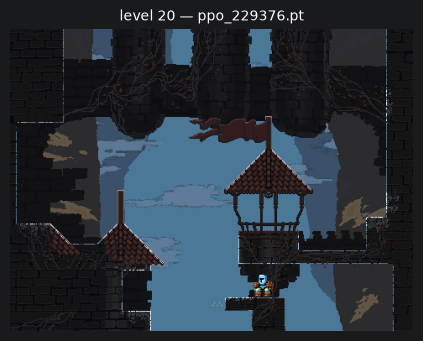

In [17]:
def load_level_model(level):
    "The deployed checkpoint for a level + an env built with ITS action table."
    files = [f for f in glob.glob(f"checkpoints/L{level}/*.pt")
             if not any(s in f.lower() for s in ("temp", "backup"))]
    path = max(files, key=lambda p: int("".join(c for c in os.path.basename(p)
                                                if c.isdigit()) or 0))
    ck = torch.load(path, map_location="cpu", weights_only=False)
    cfg = ck.get("action_cfg") or {}            # older checkpoints: the 23-action default
    e = make_env(goal_level=level + 1, max_steps=60,
                 start_states=f"starts/starts_L{level}.json", p_bottom=0.0,
                 fine_walk_frames=cfg.get("fine_walk_frames", 0),
                 extra_charges=tuple(cfg.get("extra_charges", ())))
    model = MiniActorCritic(e.grid_shape, e.n_scalars, e.num_actions).to(DEV)
    model.load_state_dict(ck["model"])          # identical architecture -> loads as-is
    model.eval()
    return model, e, os.path.basename(path), cfg


LEVEL = 20
model, env, name, cfg = load_level_model(LEVEL)     # `env` rebound again
print(f"L{LEVEL}: {name} | action_cfg={cfg} | {env.num_actions} actions | "
      f"pool={len(env._start_pool)} states")

wins = 0
for ep in range(10):
    obs, _ = env.reset()
    for t in range(40):
        with torch.no_grad():
            a = int(model(torch.as_tensor(obs, device=DEV).float().unsqueeze(0))[0].argmax(1))
        obs, r, term, trunc, info = env.step(a)
        if term or trunc:
            break
    wins += bool(info["success"])
print(f"greedy success from its own start pool: {wins}/10")

show(env, f"level {LEVEL} — {name}")
plt.show()

---

## Where to go next in the repo

| you want | file |
|---|---|
| the full env (wind, ice, macros, frontier capture) | `JK_Env.py` |
| the production PPO (subprocess envs, resume, curriculum logging) | `Train.py`, `PPO.py`, `VecEnv.py` |
| the whole 0 → 42 run | `FullRelay.py` |
| per-level automation (handoff → seed → route proof → train) | `AutoPilot.py` |
| BFS proof that a route exists | `LevelGraph.py` |
| cloning a known-good jump sequence when PPO cannot find it | `BC.py` |
| ablations and generalisation results | `thesis/ABLATION_SUMMARY.md` |